In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


1 seul cellule vide dans ChestPainType

In [37]:
df = pd.read_csv("./data/heart.csv")
df_encoded = df.copy()
df_encoded.drop(["ExerciseAngina"],axis=1, inplace=True)
df_encoded = pd.get_dummies(df_encoded, columns=["Sex", "ChestPainType", "RestingECG", "ST_Slope"])
df_encoded["ExerciseAngina"] =  df["ExerciseAngina"].map({"N":0,"Y":1})
df_encoded

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,ExerciseAngina
0,40,140,289,0,172,0.0,0,False,True,False,False,False,False,False,True,False,False,False,True,0
1,49,160,180,0,156,1.0,1,True,False,False,False,True,False,False,True,False,False,True,False,0
2,37,130,283,0,98,0.0,0,False,True,False,True,False,False,False,False,True,False,False,True,0
3,48,138,214,0,108,1.5,1,True,False,True,False,False,False,False,True,False,False,True,False,1
4,54,150,195,0,122,0.0,0,False,True,False,False,True,False,False,True,False,False,False,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1,False,True,False,False,False,True,False,True,False,False,True,False,0
914,68,144,193,1,141,3.4,1,False,True,True,False,False,False,False,True,False,False,True,False,0
915,57,130,131,0,115,1.2,1,False,True,True,False,False,False,False,True,False,False,True,False,1
916,57,130,236,0,174,0.0,1,True,False,False,True,False,False,True,False,False,False,True,False,0


In [38]:
# Split features and target
X = df_encoded.drop("HeartDisease", axis=1)
y = df_encoded["HeartDisease"]

# Scale features for k-NN and Logistic Regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)


In [39]:
# k-NN model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Fit the model
knn_model.fit(X_train, y_train)

# Predictions and probabilities
y_pred_knn = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

# Create comparison table
knn_comparison = pd.DataFrame({
    "True": y_test.values,
    "Predicted": y_pred_knn,
    "Probability": y_prob_knn
})
print("k-NN - First comparison")
print(knn_comparison.head(10))


k-NN - First comparison
   True  Predicted  Probability
0     0          0          0.0
1     1          1          0.6
2     1          1          1.0
3     1          1          1.0
4     0          0          0.2
5     1          1          0.6
6     1          1          0.8
7     0          0          0.4
8     1          1          0.8
9     1          1          1.0


Decision Tree - Top 10 Features
              Feature  Importance
17        ST_Slope_Up    0.612590
5             Oldpeak    0.097710
8   ChestPainType_ASY    0.094665
2         Cholesterol    0.045503
4               MaxHR    0.034892
7               Sex_M    0.031599
0                 Age    0.022883
3           FastingBS    0.020939
18     ExerciseAngina    0.015661
14      RestingECG_ST    0.009090


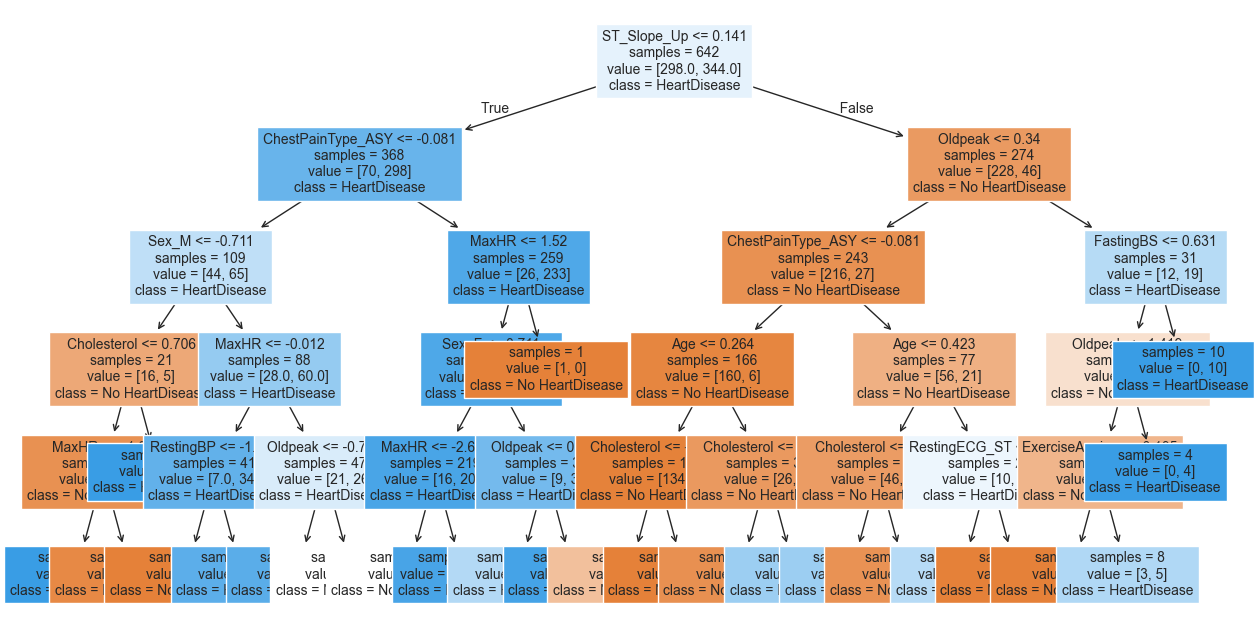

In [43]:
# Decision Tree model with limited depth for readability
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)

# Feature importances
dt_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Decision Tree - Top 10 Features")
print(dt_importances.head(10))

# Plot the decision tree
plt.figure(figsize=(15,8))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["No HeartDisease", "HeartDisease"],
    filled=True,
    impurity=False,
    proportion=False,
    fontsize=10
)
plt.show()


In [41]:
# Logistic Regression model
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
log_model.fit(X_train, y_train)

# Make predictions
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

# Feature coefficients
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print("Logistic Regression - Top features increasing risk")
print(coeff_df.head(10))
print("Logistic Regression - Top features decreasing risk")
print(coeff_df.tail(10))

# Compare true values, predictions, and probabilities
log_comparison = pd.DataFrame({
    "True": y_test.values,
    "Predicted": y_pred_log,
    "Probability": y_prob_log
})
print("Logistic Regression - First comparison")
print(log_comparison.head(10))


Logistic Regression - Top features increasing risk
              Feature  Coefficient
16      ST_Slope_Flat     0.606878
18     ExerciseAngina     0.491863
5             Oldpeak     0.477660
8   ChestPainType_ASY     0.439179
3           FastingBS     0.432250
7               Sex_M     0.240016
0                 Age     0.156099
12     RestingECG_LVH     0.066585
1           RestingBP     0.023205
13  RestingECG_Normal     0.020174
Logistic Regression - Top features decreasing risk
              Feature  Coefficient
13  RestingECG_Normal     0.020174
4               MaxHR    -0.044279
15      ST_Slope_Down    -0.068437
11   ChestPainType_TA    -0.074996
14      RestingECG_ST    -0.092951
9   ChestPainType_ATA    -0.224388
6               Sex_F    -0.240016
10  ChestPainType_NAP    -0.260534
2         Cholesterol    -0.424287
17        ST_Slope_Up    -0.577917
Logistic Regression - First comparison
   True  Predicted  Probability
0     0          0     0.024251
1     1          0     0.

In [42]:
# Dictionary of models and their predictions
models = {
    "Decision Tree": y_pred_dt,
    "k-NN": y_pred_knn,
    "Logistic Regression": y_pred_log
}

# Compute evaluation metrics for each model
metrics_list = []

for name, y_pred in models.items():
    metrics_list.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 3),
        "Precision": round(precision_score(y_test, y_pred), 3),
        "Recall": round(recall_score(y_test, y_pred), 3),
        "F1-score": round(f1_score(y_test, y_pred), 3)
    })

# Create DataFrame of metrics and display
metrics_df = pd.DataFrame(metrics_list)
print("Comparison of metrics")
print(metrics_df)


Comparison of metrics
                 Model  Accuracy  Precision  Recall  F1-score
0        Decision Tree     0.808      0.868   0.799     0.832
1                 k-NN     0.859      0.931   0.823     0.874
2  Logistic Regression     0.880      0.917   0.878     0.897


Conclusion / Interpretation

In this project, we analyzed the Heart Disease dataset using Decision Tree, k-NN, and Logistic Regression.

Decision Tree helped us see which features are most important. The top ones are ST_Slope_Flat, ChestPainType_ASY, ExerciseAngina, Oldpeak, and Sex_M. It also gives clear rules to understand who is more likely to have heart disease.

k-NN makes predictions based on similar patients. It works well for accuracy but doesn’t show which features are the most important.

Logistic Regression shows how each feature affects the risk. Positive coefficients increase the risk, negative ones decrease it. It also gives probabilities for each patient, which is useful to estimate risk.

Comparing the models, Decision Tree and Logistic Regression are easier to interpret, while k-NN is more about predicting based on patterns.

Overall, features like abnormal ST slope, asymptomatic chest pain, and exercise-induced angina are strongly linked to heart disease. Using these models together helped understand the data from different points of view: rules, probabilities, and patterns.